# UCI Online Retail — Exploratory Data Analysis

## Objective

The objective of this project is to perform an end-to-end exploratory
data analysis of the UCI Online Retail dataset, identify data-quality
issues, clean and validate the data, investigate customer and product
behavior, and derive actionable business insights.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [112]:
df.shape

(541909, 8)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [114]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [115]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [116]:
df.duplicated().sum()

np.int64(5268)

## Duplicates

In [117]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [118]:
duplicates.shape

(10147, 8)

In [119]:
duplicates.sort_values(
    by=["InvoiceNo", "StockCode", "InvoiceDate"]).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


## Negative Quantities

In [120]:
negative_qty = df[df["Quantity"] < 0]

negative_qty.shape

(10624, 8)

In [121]:
negative_qty.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [122]:
negative_qty["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [123]:
negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

## zero and negative prices

In [124]:
df[df["UnitPrice"] <= 0].shape

(2517, 8)

In [125]:
df[df["UnitPrice"] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


## Cancelled invoices

In [126]:
cancelled = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled.shape

(9288, 8)

In [127]:
cancelled.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [128]:
cancelled["Quantity"].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [129]:
cancelled["UnitPrice"].describe()

count     9288.000000
mean        48.393661
std        666.600430
min          0.010000
25%          1.450000
50%          2.950000
75%          5.950000
max      38970.000000
Name: UnitPrice, dtype: float64

## Negative quantities without cancellation

In [130]:
negative_non_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]
negative_non_cancelled.shape

(1336, 8)

In [131]:
negative_non_cancelled.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


## Zero Prices

In [132]:
df[df["UnitPrice"] == 0].shape

(2515, 8)

## Negative Prices

In [133]:
df[df["UnitPrice"]<0].shape

(2, 8)

In [134]:
df[df["UnitPrice"]<0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


## Extreme Price

In [135]:
df[df["UnitPrice"] == 38970]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.0,15098.0,United Kingdom


## Missing Description

In [136]:
df[df["Description"].isna()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


## Missing CustomerID + Transaction details

In [137]:
df[df["CustomerID"].isna()][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "Country",
]].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,United Kingdom


## Make a clean copy

In [138]:
df_clean = df.copy()

In [139]:
df_clean.shape

(541909, 8)

## Remove exact duplicates

In [140]:
df_clean = df_clean.drop_duplicates()

In [141]:
df_clean.shape

(536641, 8)

In [142]:
df_clean.duplicated().sum()

np.int64(0)

## Remove cancellation/non-sale quantities

In [143]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [144]:
## Remove zero/negative prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [145]:
df_clean.shape

(524878, 8)

In [146]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,524878.000000,524878,524878.000000,392692.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1713.539549


In [147]:
df_clean["Quantity"].describe()

count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

In [148]:
df_clean["UnitPrice"].describe()

count    524878.000000
mean          3.922573
std          36.093028
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

## Check whether problematic records remain

In [149]:
print("Negative quantities:", (df_clean["Quantity"] < 0).sum())
print("Zero quantities:", (df_clean["Quantity"] == 0).sum())
print("Negative prices:", (df_clean["UnitPrice"] < 0).sum())
print("Zero prices:", (df_clean["UnitPrice"] == 0).sum())
print("Duplicates:", df_clean.duplicated().sum())

Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0
Duplicates: 0


## Data Removed

In [150]:
rows_removed = len(df) - len(df_clean)

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", rows_removed)
print("Percentage removed:", (rows_removed / len(df)) * 100)

Original rows: 541909
Clean rows: 524878
Rows removed: 17031
Percentage removed: 3.142778584596307


In [151]:
# Check missing values
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

## Visualize Distributions

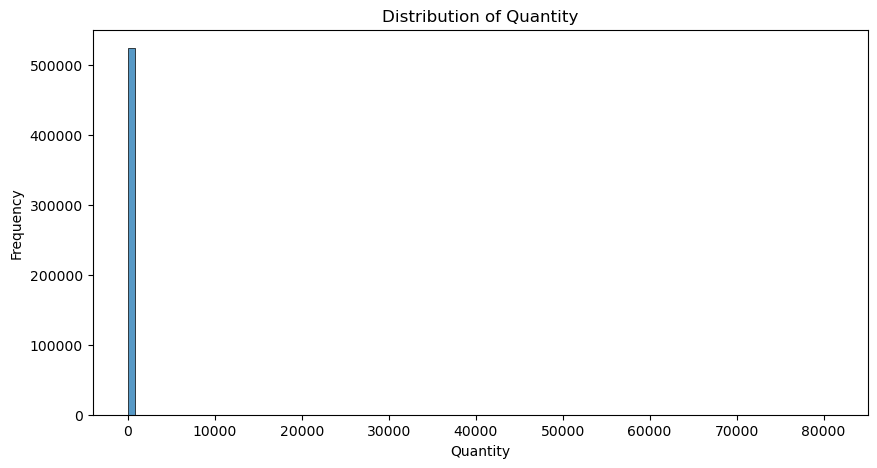

In [152]:
#Quantity Histogram
plt.figure(figsize=(10, 5))

sns.histplot(df_clean["Quantity"], bins=100)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

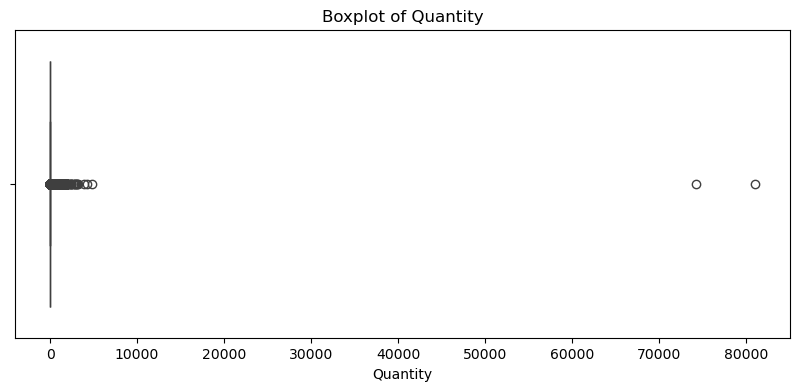

In [153]:
# Quantity Boxplot
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_clean["Quantity"])

plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")

plt.show()

## UnitPrice

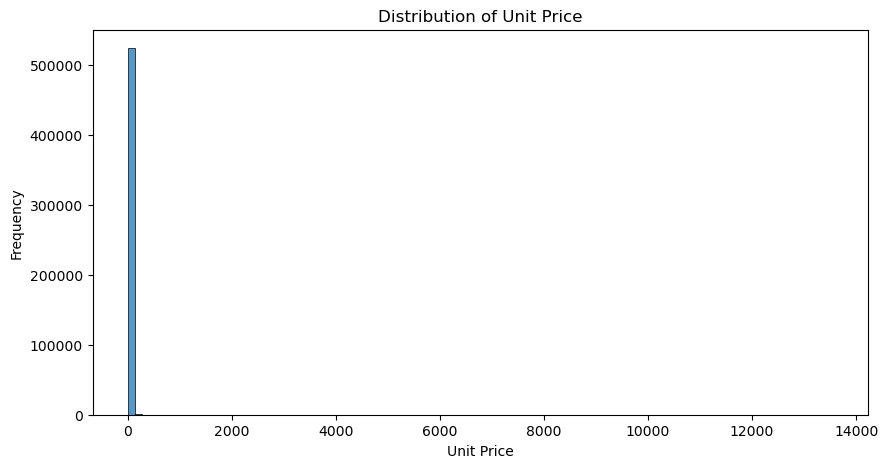

In [154]:
# Histogram
plt.figure(figsize=(10, 5))

sns.histplot(df_clean["UnitPrice"], bins=100)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

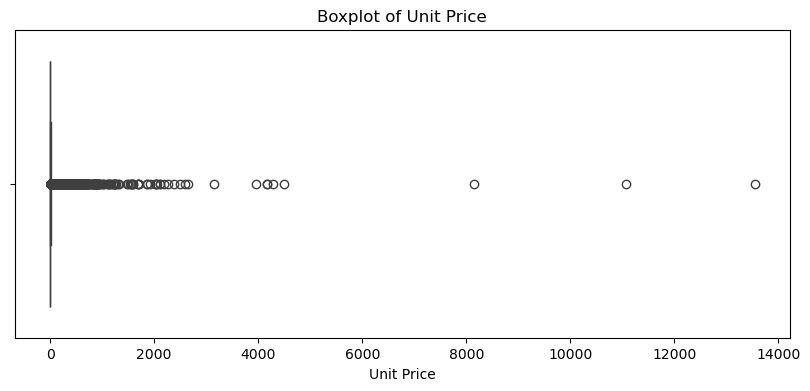

In [155]:
# Boxplot
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_clean["UnitPrice"])

plt.title("Boxplot of Unit Price")
plt.xlabel("Unit Price")

plt.show()

## IQR

In [156]:
# Quantity
Q1_quantity = df_clean["Quantity"].quantile(0.25)
Q3_quantity = df_clean["Quantity"].quantile(0.75)

IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)
print("Lower bound:", lower_quantity)
print("Upper bound:", upper_quantity)

Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower bound: -14.0
Upper bound: 26.0


In [157]:
# Flagged Observation
quantity_outliers = df_clean[
    df_clean["Quantity"] > upper_quantity
]

quantity_outliers.shape

(27111, 8)

In [158]:
quantity_outliers["Quantity"].describe()

count    27111.000000
mean        97.525101
std        681.302697
min         27.000000
25%         40.000000
50%         48.000000
75%         96.000000
max      80995.000000
Name: Quantity, dtype: float64

In [159]:
quantity_outliers.sort_values(
    "Quantity",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,12931.0,United Kingdom


In [160]:
# UnitPrice
Q1_price = df_clean["UnitPrice"].quantile(0.25)
Q3_price = df_clean["UnitPrice"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower bound:", lower_price)
print("Upper bound:", upper_price)

Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower bound: -3.0700000000000003
Upper bound: 8.45


In [161]:
price_outliers = df_clean[
    df_clean["UnitPrice"] > upper_price
]

price_outliers.shape

(37827, 8)

In [162]:
price_outliers.sort_values(
    "UnitPrice", ascending = False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,2011-08-11 10:14:00,4505.17,NaN,United Kingdom
268028,560373,M,Manual,1,2011-07-18 12:30:00,4287.63,NaN,United Kingdom
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,2011-09-19 16:14:00,2653.95,NaN,Hong Kong


## Maximum Quantity

In [163]:
df_clean[df_clean["Quantity"] == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [164]:
df_clean[df_clean["CustomerID"] == 16446]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [165]:
df_clean[df_clean["StockCode"] == 23843]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [166]:
df_clean[
    df_clean["UnitPrice"] > upper_price
][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    "CustomerID",
    "Country"
]].head(50)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
16,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,9.95,13047.0,United Kingdom
45,536370,POST,POSTAGE,3,18.00,12583.0,France
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,10.95,15100.0,United Kingdom
151,536382,22839,3 TIER CAKE TIN GREEN AND CREAM,2,14.95,16098.0,United Kingdom
152,536382,22838,3 TIER CAKE TIN RED AND CREAM,2,14.95,16098.0,United Kingdom
153,536382,22783,SET 3 WICKER OVAL BASKETS W LIDS,4,16.95,16098.0,United Kingdom
163,536384,21340,CLASSIC METAL BIRDCAGE PLANT HOLDER,2,12.75,18074.0,United Kingdom
167,536384,22424,ENAMEL BREAD BIN CREAM,8,10.95,18074.0,United Kingdom
168,536385,22783,SET 3 WICKER OVAL BASKETS W LIDS,1,19.95,17420.0,United Kingdom
173,536385,22168,ORGANISER WOOD ANTIQUE WHITE,2,8.50,17420.0,United Kingdom


In [167]:
df_clean[
    df_clean["UnitPrice"] > upper_price
]["Description"].value_counts().head(20)

Description
REGENCY CAKESTAND 3 TIER            2004
POSTAGE                             1091
DOTCOM POSTAGE                       697
IVORY KITCHEN SCALES                 677
RED RETROSPOT CAKE STAND             531
CREAM SWEETHEART MINI CHEST          523
RED KITCHEN SCALES                   509
VINTAGE UNION JACK BUNTING           478
ENAMEL BREAD BIN CREAM               453
PICNIC BASKET WICKER LARGE           443
RED DINER WALL CLOCK                 430
WHITE WOOD GARDEN PLANT LADDER       429
VINTAGE CREAM DOG FOOD CONTAINER     403
IVORY DINER WALL CLOCK               400
SWEETHEART CAKESTAND 3 TIER          377
BREAD BIN DINER STYLE IVORY          375
REGENCY TEAPOT ROSES                 361
WOODEN ROUNDERS GARDEN SET           355
BLUE DINER WALL CLOCK                349
3 HOOK PHOTO SHELF ANTIQUE WHITE     349
Name: count, dtype: int64

## Non-product transaction codes

In [168]:
df_clean[df_clean["StockCode"].isin(["POST", "DOT", "M", "AMAZONFEE"])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom
...,...,...,...,...,...,...,...,...
541216,581494,POST,POSTAGE,2,2011-12-09 10:13:00,18.00,12518.0,Germany
541540,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,NaN,United Kingdom
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany


In [169]:
df_clean[
    df_clean["StockCode"].isin(["POST", "DOT", "M", "AMAZONFEE"])
]["Description"].value_counts()

Description
POSTAGE           1126
DOTCOM POSTAGE     706
Manual             316
AMAZON FEE           2
Name: count, dtype: int64

In [170]:
df_clean[
    df_clean["StockCode"].isin(["POST", "DOT", "M", "AMAZONFEE"])
].groupby("StockCode")["UnitPrice"].agg(
    ["count", "min", "median", "max"]
)

,count,min,median,max
StockCode,,,,
AMAZONFEE,2,219.76,6880.545,13541.33
DOT,706,0.35,185.470,4505.17
M,316,0.06,1.950,4287.63
POST,1126,0.55,18.000,8142.75


## Handling outliers

In [171]:
#Quantity outliers
df_clean["Quantity_Outlier"] = (
    df_clean["Quantity"] > upper_quantity
)

In [172]:
#UnitPrice outliers
df_clean["UnitPrice_Outlier"] = (
    df_clean["UnitPrice"] > upper_price
)

## Create df Analysis

In [173]:
df_analysis = df_clean[
    ~(
        (df_clean["InvoiceNo"] == 581483) &
        (df_clean["StockCode"] == 23843) &
        (df_clean["Quantity"] == 80995)
    )
].copy()

In [174]:
non_product_codes = ["POST", "DOT", "M", "AMAZONFEE"]

df_analysis = df_analysis[
    ~df_analysis["StockCode"].isin(non_product_codes)
].copy()

In [175]:
df_analysis.shape

(522727, 10)

In [176]:
df_analysis["StockCode"].isin(non_product_codes).sum()

np.int64(0)

In [177]:
df_analysis[df_analysis["Quantity"]==80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_Outlier,UnitPrice_Outlier


In [178]:
df_analysis["TotalAmount"] = (
    df_analysis["Quantity"] * df_analysis["UnitPrice"]
)

In [179]:
df_analysis[
    ["Quantity", "UnitPrice", "TotalAmount"]
].head(10)

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [180]:
df_analysis["TotalAmount"].describe()

count    522727.000000
mean         19.317501
std         137.078330
min           0.001000
25%           3.900000
50%           9.900000
75%          17.700000
max       77183.600000
Name: TotalAmount, dtype: float64

## TotalAmount Outlier

In [181]:
Q1_amount = df_analysis["TotalAmount"].quantile(0.25)
Q3_amount = df_analysis["TotalAmount"].quantile(0.75)

IQR_amount = Q3_amount - Q1_amount

upper_amount = Q3_amount + 1.5 * IQR_amount

print("Q1:", Q1_amount)
print("Q3:", Q3_amount)
print("IQR:", IQR_amount)
print("Upper bound:", upper_amount)

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Upper bound: 38.400000000000006


In [182]:
amount_outliers = df_analysis[
    df_analysis["TotalAmount"] > upper_amount
]

print("Outlier transactions:", len(amount_outliers))

Outlier transactions: 41261


In [183]:
amount_outliers.sort_values(
    "TotalAmount",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_Outlier,UnitPrice_Outlier,TotalAmount
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,True,False,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,True,True,38970.00
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,False,True,11062.06
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,True,False,7144.72
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,True,False,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,True,False,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,True,False,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749.0,United Kingdom,True,False,4921.50
467804,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,2011-11-14 17:55:00,6.95,NaN,United Kingdom,True,False,4781.60
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749.0,United Kingdom,True,False,4632.00


## Visualize cleaned distribution

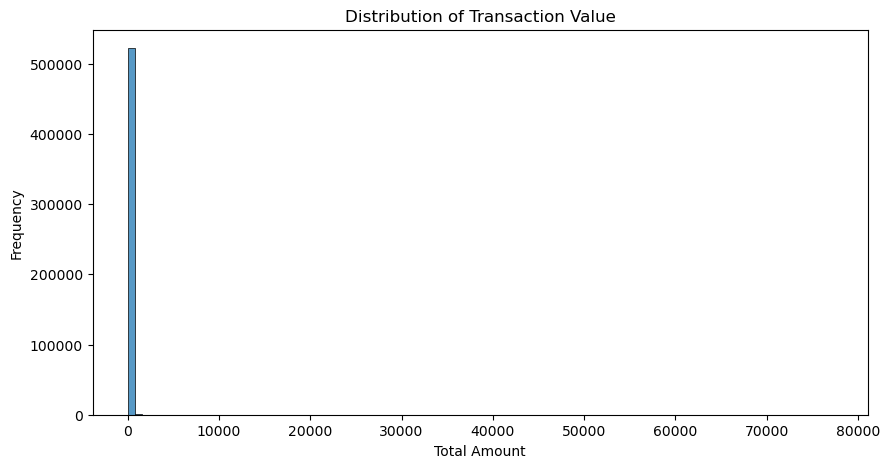

In [184]:
#TotalAmount Histogram
plt.figure(figsize=(10, 5))

sns.histplot(
    df_analysis["TotalAmount"],
    bins=100
)

plt.title("Distribution of Transaction Value")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

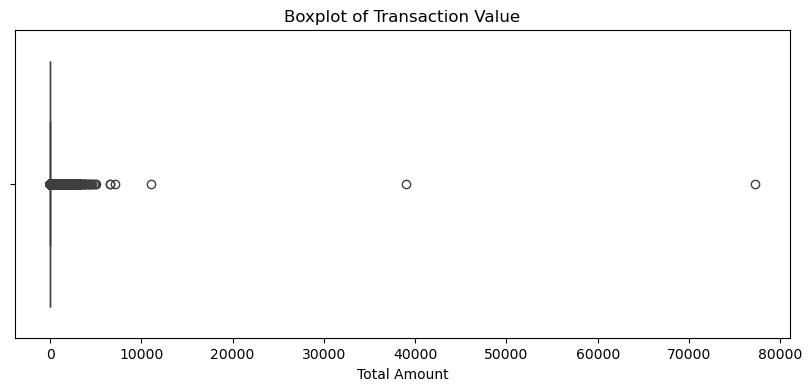

In [185]:
#TotalAmount boxplot
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_analysis["TotalAmount"]
)

plt.title("Boxplot of Transaction Value")
plt.xlabel("Total Amount")

plt.show()

In [186]:
#CustomerId 12346
df_analysis[df_analysis["CustomerID"] == 12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_Outlier,UnitPrice_Outlier,TotalAmount
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,True,False,77183.6


In [187]:
df_analysis[df_analysis["StockCode"] == 23166]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_Outlier,UnitPrice_Outlier,TotalAmount
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,True,False,77183.60
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-05-12 10:10:00,1.04,14646.0,Netherlands,True,False,99.84
187196,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-05-12 12:11:00,1.25,16745.0,United Kingdom,False,False,5.00
187718,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2011-05-12 16:29:00,1.25,14651.0,United Kingdom,False,False,6.25
187868,553009,23166,MEDIUM CERAMIC TOP STORAGE JAR,3,2011-05-12 16:52:00,1.25,13601.0,United Kingdom,False,False,3.75
...,...,...,...,...,...,...,...,...,...,...,...
533742,581108,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-07 12:16:00,1.25,15984.0,United Kingdom,False,False,2.50
536248,581219,23166,MEDIUM CERAMIC TOP STORAGE JAR,1,2011-12-08 09:28:00,2.46,NaN,United Kingdom,False,False,2.46
539776,581439,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-08 16:30:00,2.46,NaN,United Kingdom,False,False,4.92
540301,581476,23166,MEDIUM CERAMIC TOP STORAGE JAR,48,2011-12-09 08:48:00,1.04,12433.0,Norway,True,False,49.92


In [188]:
df_analysis[
    df_analysis["Quantity"] > 10000
][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    "CustomerID",
    "Country",
    "TotalAmount"
]].sort_values("Quantity", ascending=False)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,TotalAmount
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom,77183.6


In [189]:
#Bad debt records
df_analysis[df_analysis["StockCode"] == "B"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_Outlier,UnitPrice_Outlier,TotalAmount
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,False,True,11062.06


In [190]:
#Missing CustomerId analysis
print("Missing CustomerID:",
      df_analysis["CustomerID"].isna().sum())

print("Percentage missing:",
      df_analysis["CustomerID"].isna().mean() * 100)

Missing CustomerID: 131430
Percentage missing: 25.143143552944462


In [191]:
df_analysis.groupby(
    df_analysis["CustomerID"].isna()
)["TotalAmount"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
CustomerID,,,,
False,391297,21.915857,11.90,8575609.044
True,131430,11.581604,4.96,1522170.150


In [192]:
# Remove the confirmed extreme quantity anomaly
df_analysis = df_analysis[
    ~(
        (df_analysis["InvoiceNo"] == 541431) &
        (df_analysis["StockCode"] == 23166)
    )
].copy()

# Remove bad debt adjustment
df_analysis = df_analysis[
    df_analysis["StockCode"] != "B"
].copy()

In [193]:
print("Final analysis shape:", df_analysis.shape)

print("\nMaximum Quantity:")
print(df_analysis["Quantity"].max())

print("\nMaximum TotalAmount:")
print(df_analysis["TotalAmount"].max())

print("\nRemaining StockCode B:")
print(df_analysis[df_analysis["StockCode"] == "B"].shape)

Final analysis shape: (522725, 11)

Maximum Quantity:
4800

Maximum TotalAmount:
38970.0

Remaining StockCode B:
(0, 11)


## Final data-quality report

In [194]:
print("========== FINAL DATA QUALITY REPORT ==========")

print("\nShape:", df_analysis.shape)

print("\nMissing values:")
print(df_analysis.isnull().sum())

print("\nDuplicates:", df_analysis.duplicated().sum())

print("\nNegative quantities:",
      (df_analysis["Quantity"] < 0).sum())

print("Zero quantities:",
      (df_analysis["Quantity"] == 0).sum())

print("Negative prices:",
      (df_analysis["UnitPrice"] < 0).sum())

print("Zero prices:",
      (df_analysis["UnitPrice"] == 0).sum())

print("\nMinimum Quantity:",
      df_analysis["Quantity"].min())

print("Maximum Quantity:",
      df_analysis["Quantity"].max())

print("\nMinimum UnitPrice:",
      df_analysis["UnitPrice"].min())

print("Maximum UnitPrice:",
      df_analysis["UnitPrice"].max())

print("\nMinimum TotalAmount:",
      df_analysis["TotalAmount"].min())

print("Maximum TotalAmount:",
      df_analysis["TotalAmount"].max())

========== FINAL DATA QUALITY REPORT ==========

Shape: (522725, 11)

Missing values:
InvoiceNo                 0
StockCode                 0
Description               0
Quantity                  0
InvoiceDate               0
UnitPrice                 0
CustomerID           131429
Country                   0
Quantity_Outlier          0
UnitPrice_Outlier         0
TotalAmount               0
dtype: int64

Duplicates: 0

Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0

Minimum Quantity: 1
Maximum Quantity: 4800

Minimum UnitPrice: 0.001
Maximum UnitPrice: 649.5

Minimum TotalAmount: 0.001
Maximum TotalAmount: 38970.0


## EDA Visualizations

In [195]:
df_analysis["Quantity"].describe()

count    522725.000000
mean         10.342660
std          37.847626
min           1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max        4800.000000
Name: Quantity, dtype: float64

In [196]:
df_analysis["Quantity"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     24.000
0.950     30.000
0.990    100.000
0.995    160.000
0.999    448.552
Name: Quantity, dtype: float64

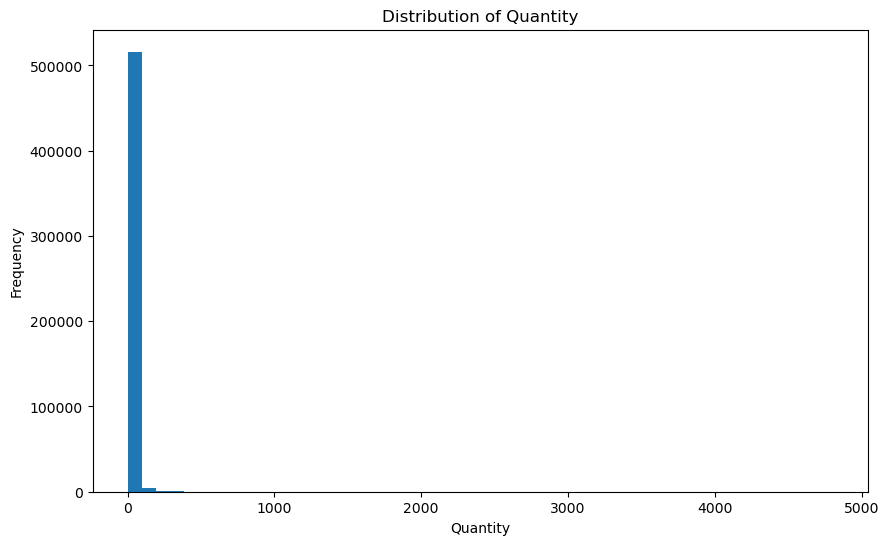

In [197]:
#Quantity histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df_analysis["Quantity"], bins=50)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
#plt.savefig('Distriution of quantity.png', dpi=300, bbox_inches='tight')
plt.show()

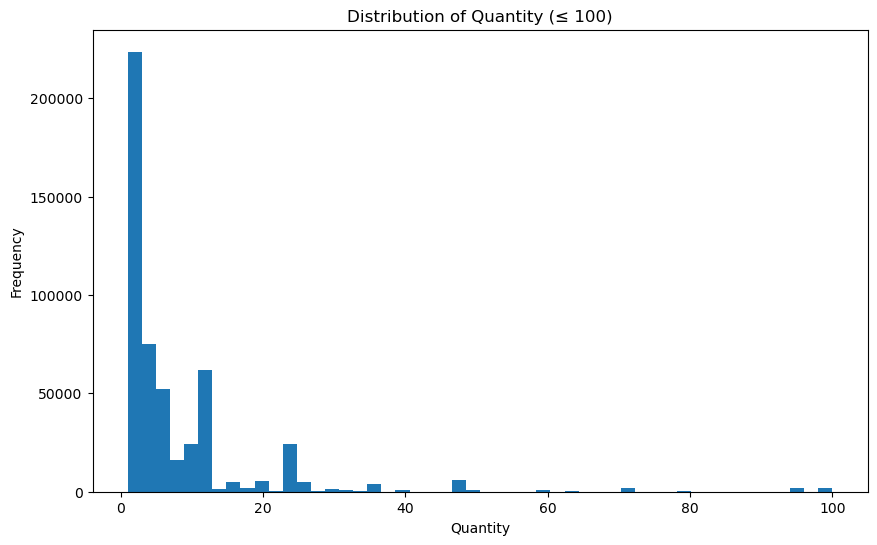

In [198]:
#Focused View
plt.figure(figsize=(10, 6))

plt.hist(
    df_analysis.loc[df_analysis["Quantity"] <= 100, "Quantity"],
    bins=50
)

plt.title("Distribution of Quantity (≤ 100)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
#plt.savefig('Distriution of quantity_focused.png', dpi=300, bbox_inches='tight')

plt.show()

In [199]:
# For UnitPrice
df_analysis["UnitPrice"].describe()

count    522725.000000
mean          3.287974
std           4.465104
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max         649.500000
Name: UnitPrice, dtype: float64

In [200]:
df_analysis["UnitPrice"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     7.65
0.950     9.95
0.990    16.63
0.995    20.79
0.999    39.95
Name: UnitPrice, dtype: float64

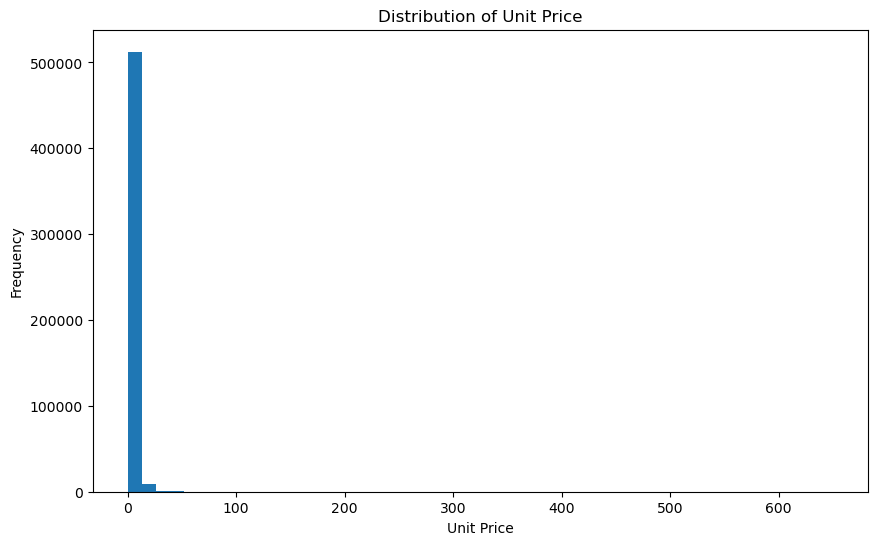

In [201]:
# UnitPrice Histogram
plt.figure(figsize=(10, 6))

plt.hist(df_analysis["UnitPrice"], bins=50)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
#plt.savefig('Distriution of unit price.png', dpi=300, bbox_inches='tight')

plt.show()

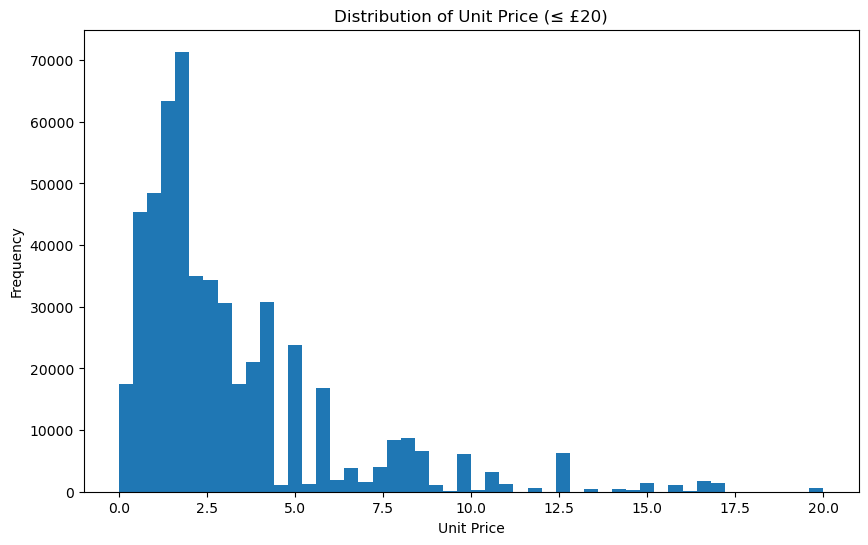

In [202]:
# UnitPrice focused view
plt.figure(figsize=(10, 6))

plt.hist(
    df_analysis.loc[df_analysis["UnitPrice"] <= 20, "UnitPrice"],
    bins=50
)

plt.title("Distribution of Unit Price (≤ £20)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
#plt.savefig('Distriution of unit price_focused.png', dpi=300, bbox_inches='tight')
plt.show()

In [203]:
#Quantify the skewness
df_analysis["UnitPrice"].skew()

np.float64(24.867479074619844)

In [204]:
# percentage of transactions that are relatively inexpensive
(df_analysis["UnitPrice"] <= 10).mean() * 100

np.float64(95.79300779568607)

In [205]:
(df_analysis["UnitPrice"] <= 20).mean() * 100

np.float64(99.47658902864795)

In [206]:
# For TotalAmount
df_analysis["TotalAmount"].describe()

count    522725.000000
mean         19.148756
std          84.653842
min           0.001000
25%           3.900000
50%           9.900000
75%          17.700000
max       38970.000000
Name: TotalAmount, dtype: float64

In [207]:
df_analysis["TotalAmount"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     31.8
0.950     59.4
0.990    179.0
0.995    275.0
0.999    750.0
Name: TotalAmount, dtype: float64

In [208]:
df_analysis["TotalAmount"].skew()

np.float64(200.83259009940537)

In [209]:
(df_analysis["TotalAmount"] <= 50).mean() * 100

np.float64(94.30178392079965)

In [210]:
(df_analysis["TotalAmount"] <= 100).mean() * 100

np.float64(97.57635467980296)

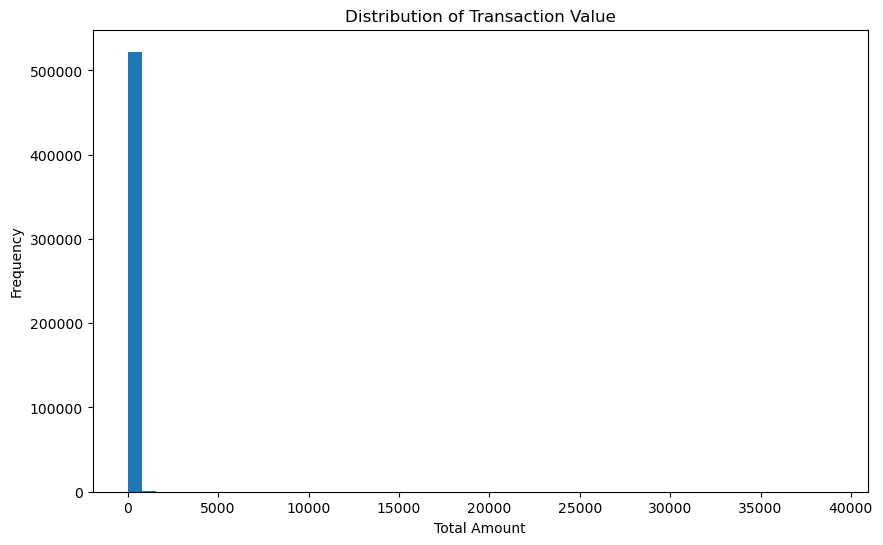

In [211]:
# TotalAmount Histogram
plt.figure(figsize=(10, 6))

plt.hist(df_analysis["TotalAmount"], bins=50)

plt.title("Distribution of Transaction Value")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
#plt.savefig('Distriution of transaction value.png', dpi=300, bbox_inches='tight')
plt.show()

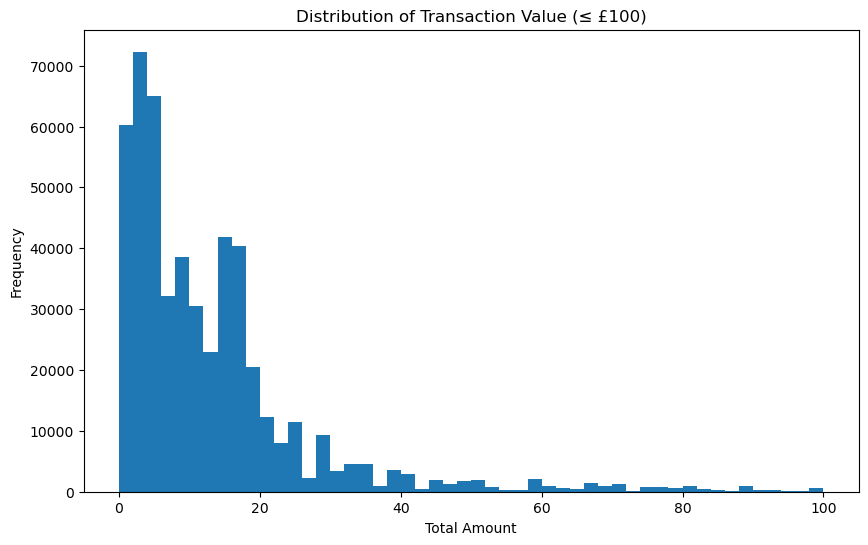

In [212]:
#TotalAmount focused view
plt.figure(figsize=(10, 6))

plt.hist(
    df_analysis.loc[df_analysis["TotalAmount"] <= 100, "TotalAmount"],
    bins=50
)

plt.title("Distribution of Transaction Value (≤ £100)")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
#plt.savefig('Distriution of transaction value_focused.png', dpi=300, bbox_inches='tight')
plt.show()

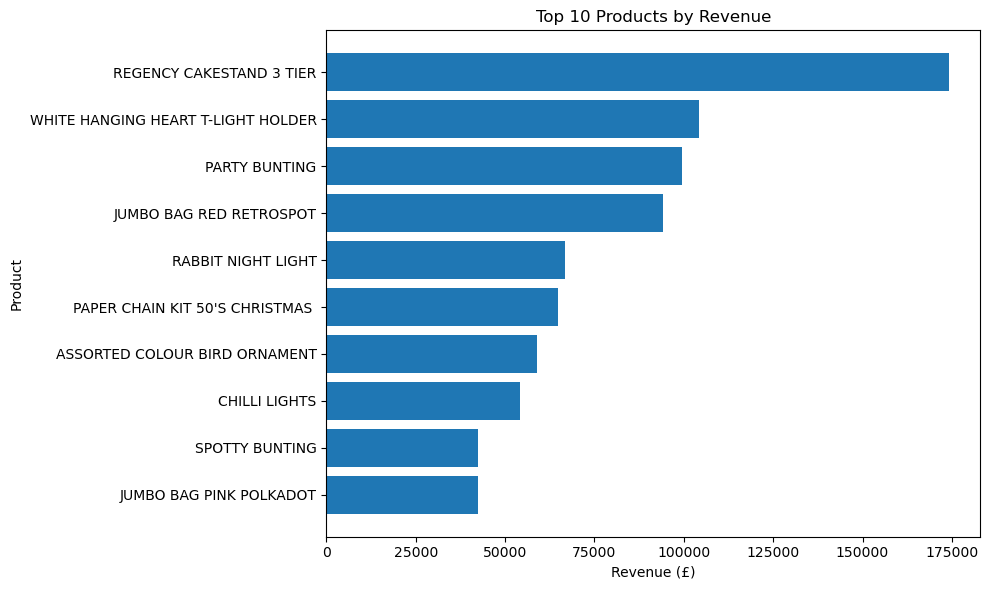

In [213]:
#Top products by revenue
top_revenue = (
    df_analysis
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Revenue=("TotalAmount", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue["Description"].iloc[::-1],
    top_revenue["Revenue"].iloc[::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
#plt.savefig('Top products by revenue.png', dpi=300, bbox_inches='tight')
plt.show()

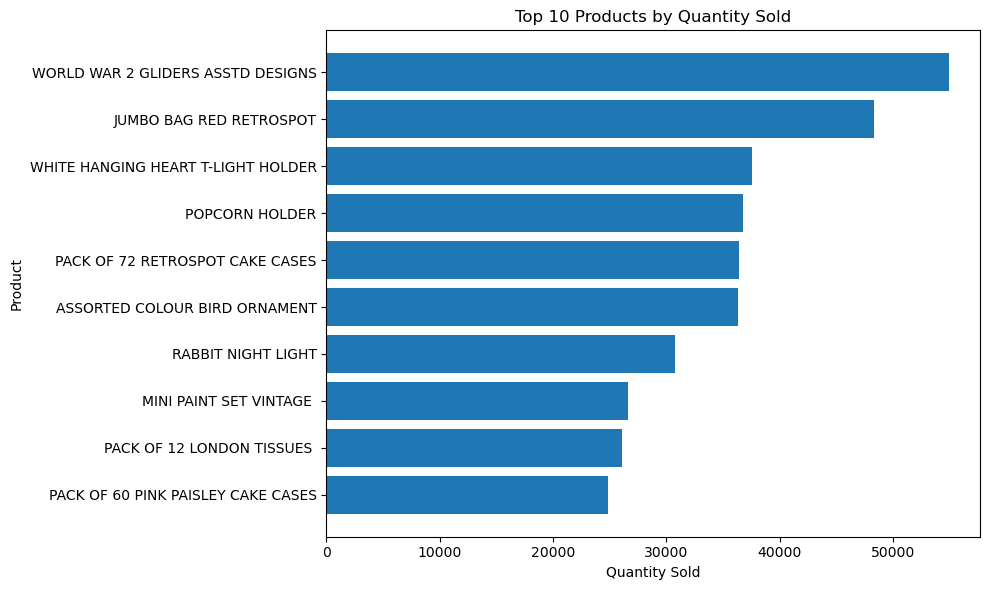

In [214]:
#Top products by quantity by quantity sold
top_quantity = (
    df_analysis
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Quantity=("Quantity", "sum")
    )
    .sort_values("Quantity", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_quantity["Description"].iloc[::-1],
    top_quantity["Quantity"].iloc[::-1]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
#plt.savefig('Top products by quantity.png', dpi=300, bbox_inches='tight')
plt.show()

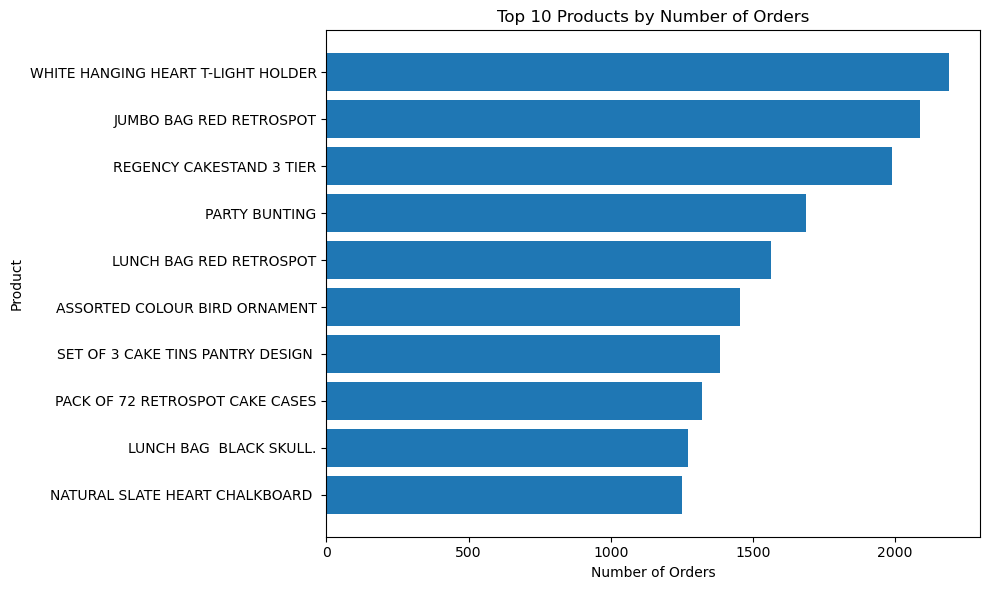

In [215]:
#Top 10 products by number of orders
top_orders = (
    df_analysis
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Orders", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_orders["Description"].iloc[::-1],
    top_orders["Orders"].iloc[::-1]
)

plt.title("Top 10 Products by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product")

plt.tight_layout()
#plt.savefig('Top products by orders.png', dpi=300, bbox_inches='tight')
plt.show()

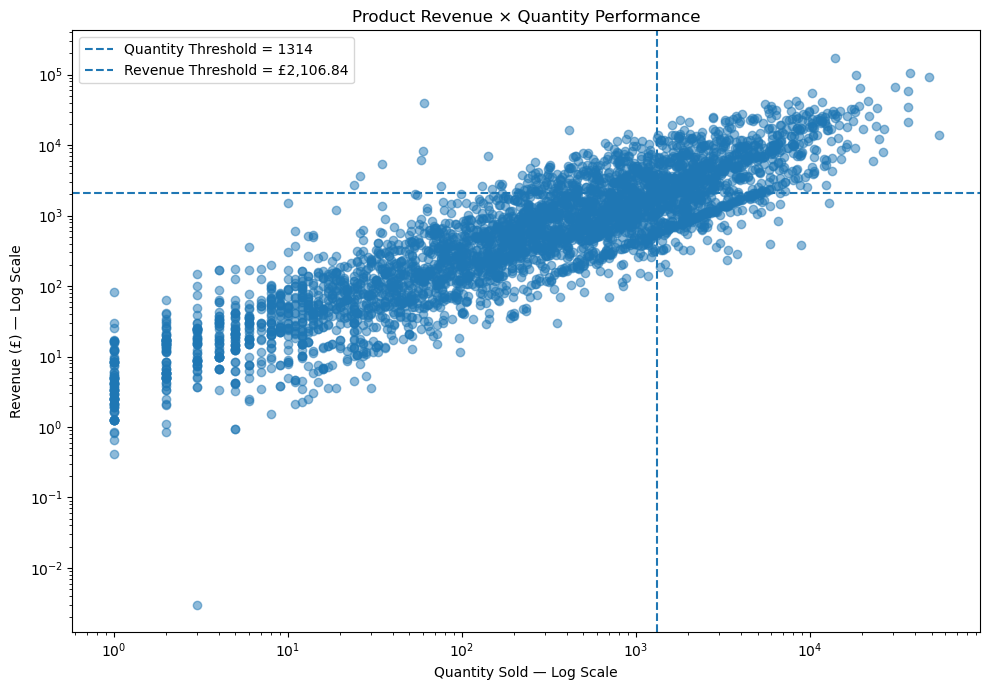

In [216]:
#Product revenue * Quantity performance matrix
product_performance = (
    df_analysis
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Revenue=("TotalAmount", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

revenue_threshold = product_performance["Revenue"].quantile(0.75)
quantity_threshold = product_performance["Quantity"].quantile(0.75)

product_performance["Performance"] = np.select(
    [
        (product_performance["Revenue"] >= revenue_threshold) &
        (product_performance["Quantity"] >= quantity_threshold),

        (product_performance["Revenue"] >= revenue_threshold) &
        (product_performance["Quantity"] < quantity_threshold),

        (product_performance["Revenue"] < revenue_threshold) &
        (product_performance["Quantity"] >= quantity_threshold)
    ],
    [
        "High Revenue & High Volume",
        "High Revenue & Low Volume",
        "Low Revenue & High Volume"
    ],
    default="Low Revenue & Low Volume"
)


plt.figure(figsize=(10, 7))

plt.scatter(
    product_performance["Quantity"],
    product_performance["Revenue"],
    alpha=0.5
)

plt.axvline(
    quantity_threshold,
    linestyle="--",
    label=f"Quantity Threshold = {quantity_threshold:.0f}"
)

plt.axhline(
    revenue_threshold,
    linestyle="--",
    label=f"Revenue Threshold = £{revenue_threshold:,.2f}"
)

plt.xscale("log")
plt.yscale("log")

plt.title("Product Revenue × Quantity Performance")
plt.xlabel("Quantity Sold — Log Scale")
plt.ylabel("Revenue (£) — Log Scale")

plt.legend()

plt.tight_layout()
#plt.savefig('Product Revenue × Quantity Performance.png', dpi=300, bbox_inches='tight')
plt.show()

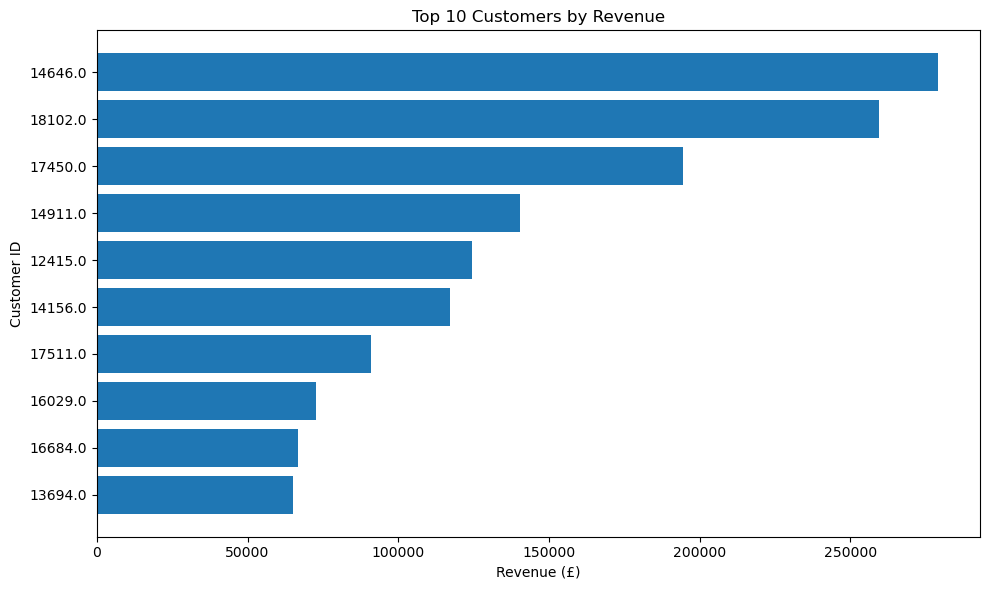

In [217]:
#Top 10 customers by revenue

customer_revenue = (
    df_analysis
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Revenue=("TotalAmount", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    customer_revenue.index.astype(str)[::-1],
    customer_revenue["Revenue"].iloc[::-1]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
#plt.savefig('Top 10 Customers by Revenue.png', dpi=300, bbox_inches='tight')
plt.show()

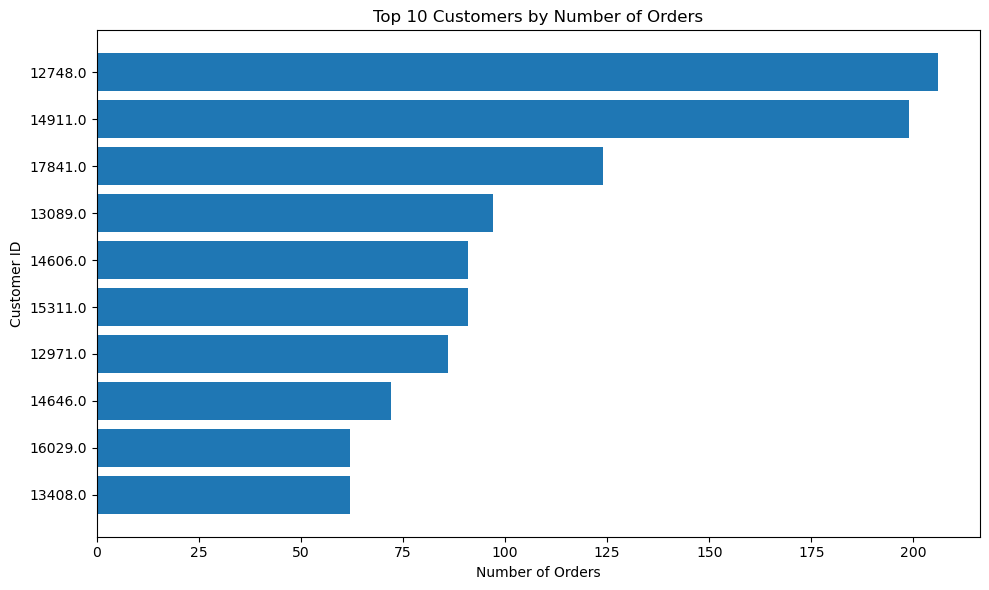

In [218]:
#Top 10 customers by order count

customer_orders = (
    df_analysis
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    customer_orders.index.astype(str)[::-1],
    customer_orders["Orders"].iloc[::-1]
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.tight_layout()
#plt.savefig('Top 10 Customers by Number of Orders.png', dpi=300, bbox_inches='tight')
plt.show()

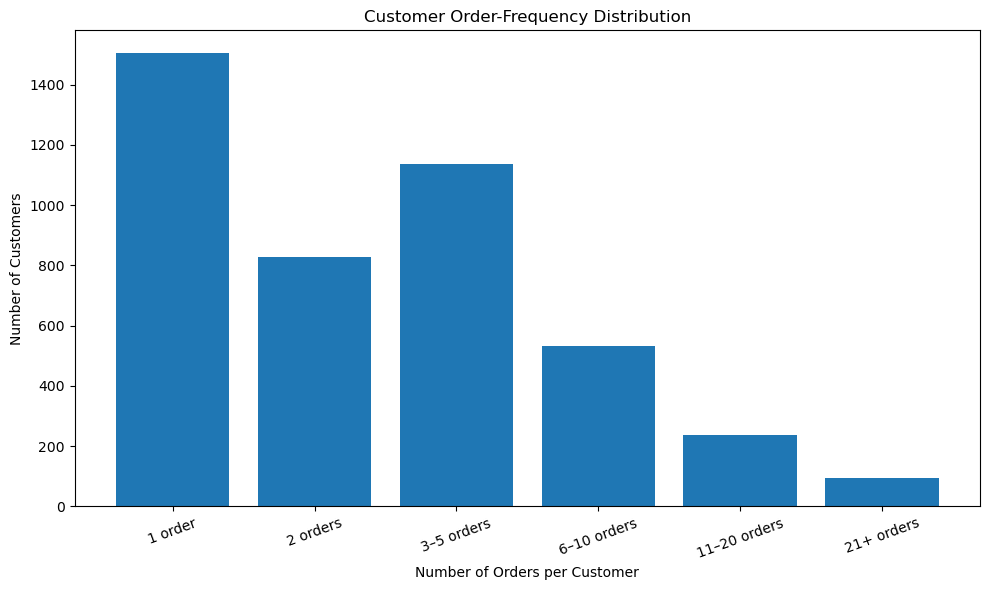

In [219]:
# Customer-Order frequency distribution
customer_frequency = (
    df_analysis
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

frequency_bins = pd.cut(
    customer_frequency,
    bins=[0, 1, 2, 5, 10, 20, np.inf],
    labels=[
        "1 order",
        "2 orders",
        "3–5 orders",
        "6–10 orders",
        "11–20 orders",
        "21+ orders"
    ]
)

frequency_distribution = frequency_bins.value_counts().reindex(
    [
        "1 order",
        "2 orders",
        "3–5 orders",
        "6–10 orders",
        "11–20 orders",
        "21+ orders"
    ]
)

plt.figure(figsize=(10, 6))

plt.bar(
    frequency_distribution.index,
    frequency_distribution.values
)

plt.title("Customer Order-Frequency Distribution")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
#plt.savefig('Customer-Order Frequency Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [220]:
# RFM Distribution
rfm_score_distribution = (
    rfm["RFM_Score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    rfm_score_distribution.index.astype(str),
    rfm_score_distribution.values
)

plt.title("RFM Score Distribution")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
#plt.savefig('RFM Score distribution.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'rfm' is not defined

In [ ]:
#Customer segment revenue

segment_summary = (
    rfm
    .groupby("CustomerSegment")
    .agg(
        Customers=("Monetary", "count"),
        Revenue=("Monetary", "sum")
    )
)

segment_summary["CustomerPercentage"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
)

segment_summary["RevenuePercentage"] = (
    segment_summary["Revenue"]
    / segment_summary["Revenue"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "RevenuePercentage",
    ascending=False
)

x = np.arange(len(segment_summary))
width = 0.38

plt.figure(figsize=(12, 7))

plt.bar(
    x - width/2,
    segment_summary["CustomerPercentage"],
    width,
    label="Customer Share (%)"
)

plt.bar(
    x + width/2,
    segment_summary["RevenuePercentage"],
    width,
    label="Revenue Share (%)"
)

plt.title("Customer Share vs Revenue Contribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")

plt.xticks(
    x,
    segment_summary.index,
    rotation=25,
    ha="right"
)

plt.legend()

plt.tight_layout()
#plt.savefig('Revenue by Customer Segment.png', dpi=300, bbox_inches='tight')
plt.show()

## Time-based EDA

In [ ]:
df_analysis["Year"] = df_analysis["InvoiceDate"].dt.year
df_analysis["Month"] = df_analysis["InvoiceDate"].dt.month
df_analysis["Day Of Week"] = df_analysis["InvoiceDate"].dt.day_name()
df_analysis["Hour"] = df_analysis["InvoiceDate"].dt.hour

In [ ]:
df_analysis[["InvoiceDate", "Year", "Month", "Day Of Week", "Hour"]].head()

In [ ]:
df_analysis[["Year", "Month", "Day Of Week", "Hour"]].describe()

### Create a Year-Month column

In [ ]:
df_analysis["YearMonth"] = df_analysis["InvoiceDate"].dt.to_period("M")

In [ ]:
df_analysis[["InvoiceDate", "YearMonth"]].head()

### Monthly_transactions

In [ ]:
monthly_transactions = (
    df_analysis.groupby("YearMonth")
    .size()
)

In [ ]:
monthly_transactions

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values
)

plt.title("Monthly Transaction Activity")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

#plt.savefig('monthly_transactions.png', dpi=300, bbox_inches='tight') 

plt.show()

### Monthly Revenue

In [ ]:
monthly_revenue = (
    df_analysis.groupby("YearMonth")["TotalAmount"]
    .sum()
)

In [ ]:
monthly_revenue

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

#plt.savefig('monthly_revenue.png', dpi=300, bbox_inches='tight')

plt.show()

### Monthly average transaction value

In [ ]:
monthly_avg_transaction = (
    df_analysis.groupby("YearMonth")["TotalAmount"]
    .mean()
)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg_transaction.index.astype(str),
    monthly_avg_transaction.values
)

plt.title("Average Transaction Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Transaction Value (£)")

plt.xticks(rotation=45)

plt.savefig('monthly_avg_transaction.png', dpi=300, bbox_inches='tight')

plt.show()

### Day-of-Week Purchasing Behavior

In [ ]:
# Transactions by day
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_activity = (
    df_analysis.groupby('Day Of Week')
    .size()
    .reindex(day_order)
)

daily_activity

In [ ]:
plt.figure(figsize=(10, 5))

daily_activity.plot(kind='bar')

plt.title('Transaction Activity by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

#plt.savefig('Transaction Activity by Day of Week.png', dpi=300, bbox_inches='tight')

plt.show()

### Revenue by day of week

In [ ]:
daily_revenue = (
    df_analysis.groupby('Day Of Week')['TotalAmount']
    .sum()
    .reindex(day_order)
)

daily_revenue

In [ ]:
plt.figure(figsize=(10, 5))

daily_revenue.plot(kind='bar')

plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=0)

#plt.savefig('Revenue by Day of Week.png', dpi=300, bbox_inches='tight')

plt.show()

### Average Transaction Value by Day

In [ ]:
daily_avg_transaction = (
    df_analysis.groupby('Day Of Week')['TotalAmount']
    .mean()
    .reindex(day_order)
)

daily_avg_transaction

In [ ]:
plt.figure(figsize=(10, 5))

daily_avg_transaction.plot(kind='bar')

plt.title('Average Transaction Value by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Transaction Value (£)')
plt.xticks(rotation=0)
#plt.savefig('Avg Transaction Value by Day of Week.png', dpi=300, bbox_inches='tight')
plt.show()

### Transactions by hour

In [ ]:
hourly_activity = (
    df_analysis.groupby('Hour')
    .size()
)

hourly_activity

In [ ]:
plt.figure(figsize=(12, 5))

hourly_activity.plot(kind='line', marker='o')

plt.title('Hourly Transaction Activity')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(6, 21))

plt.grid(alpha=0.3)
#plt.savefig('Hourly Transaction Activity.png', dpi=300, bbox_inches='tight')
plt.show()

### Revenue by hour

In [ ]:
hourly_revenue = (
    df_analysis.groupby('Hour')['TotalAmount']
    .sum()
)

hourly_revenue

In [ ]:
plt.figure(figsize=(12, 5))

hourly_revenue.plot(kind='line', marker='o')

plt.title('Hourly Revenue')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (£)')
plt.xticks(range(6, 21))

plt.grid(alpha=0.3)
#plt.savefig('Hourly Revenue.png', dpi=300, bbox_inches='tight')
plt.show()

### Average Transaction Value by Hour

In [ ]:
hourly_avg_transaction = (
    df_analysis.groupby('Hour')['TotalAmount']
    .mean()
)

hourly_avg_transaction

In [ ]:
plt.figure(figsize=(12, 5))

hourly_avg_transaction.plot(kind='line', marker='o')

plt.title('Average Transaction Value by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Transaction Value (£)')
plt.xticks(range(6, 21))

plt.grid(alpha=0.3)
#plt.savefig('Avg Transaction Value by Hour.png', dpi=300, bbox_inches='tight')
plt.show()

### Day × Hour

In [ ]:
day_hour = pd.crosstab(
    df_analysis['Day Of Week'],
    df_analysis['Hour']
).reindex(day_order)

day_hour

In [ ]:
plt.figure(figsize=(14, 6))

sns.heatmap(day_hour, annot=True, fmt='g')

plt.title('Purchasing Activity by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
#plt.savefig('Purchasing Activity by Day and Hour.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
hour_7 = df_analysis[df_analysis['Hour'] == 7]['TotalAmount']

hour_7.describe()

In [ ]:
df_analysis.groupby('Hour')['TotalAmount'].agg(
    ['count', 'mean', 'median', 'sum']
)

## Country / Geographical Purchasing Behavior

### Country-level transaction activity

In [ ]:
country_transactions = (
    df_analysis.groupby('Country')
    .size()
    .sort_values(ascending=False)
)

country_transactions.head(15)

In [ ]:
country_transaction_pct = (
    country_transactions / country_transactions.sum() * 100
)

country_transaction_pct.head(15)

### Country-level revenue

In [ ]:
country_revenue = (
    df_analysis.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(15)

In [ ]:
country_revenue_pct = (
    country_revenue / country_revenue.sum() * 100
)

country_revenue_pct.head(15)

In [ ]:
country_value = (
    df_analysis.groupby('Country')['TotalAmount']
    .agg(['count', 'mean', 'median', 'sum'])
    .sort_values('sum', ascending=False)
)

print(country_value.head(20))

### Average transaction value by country

In [ ]:
country_avg_value = (
    df_analysis.groupby('Country')['TotalAmount']
    .mean()
    .sort_values(ascending=False)
)

country_avg_value.head(15)

### country summary

In [ ]:
country_summary = (
    df_analysis.groupby('Country')
    .agg(
        Transactions=('InvoiceNo', 'count'),
        Revenue=('TotalAmount', 'sum'),
        AvgTransactionValue=('TotalAmount', 'mean'),
        MedianTransactionValue=('TotalAmount', 'median'),
        Customers=('CustomerID', 'nunique'),
        QuantitySold=('Quantity', 'sum')
    )
    .sort_values('Revenue', ascending=False)
)

country_summary.head(15)

In [ ]:
country_summary['RevenuePct'] = (
    country_summary['Revenue'] /
    country_summary['Revenue'].sum() * 100
)

### Country Visualizations

In [ ]:
top10_revenue = country_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_revenue.index[::-1],
    top10_revenue['Revenue'][::-1]
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.savefig('top10_revenue', dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
top10_transactions = (
    country_summary
    .sort_values('Transactions', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_transactions.index[::-1],
    top10_transactions['Transactions'][::-1]
)

plt.title('Top 10 Countries by Transaction Activity')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
#plt.savefig('top10_transactions', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    country_summary['Transactions'],
    country_summary['Revenue']
)

plt.title('Country Transaction Volume vs Revenue')
plt.xlabel('Number of Transactions')
plt.ylabel('Revenue (£)')
#plt.savefig('country_summary', dpi=300, bbox_inches='tight')
plt.show()

### UK

In [ ]:
uk = country_summary.loc['United Kingdom']

uk

In [ ]:
uk['RevenuePct']

In [ ]:
non_uk = country_summary.drop('United Kingdom')

non_uk['Revenue'].sum()

In [ ]:
non_uk['Transactions'].sum()

### International markets

In [ ]:
international = (
    country_summary
    .drop('United Kingdom')
    .sort_values('Revenue', ascending=False)
)

international.head(15)

### Customer-level geographical analysis

In [ ]:
country_customers = (
    df_analysis.groupby('Country')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)

country_customers.head(15)

In [ ]:
country_summary['RevenuePerCustomer'] = (
    country_summary['Revenue'] /
    country_summary['Customers']
)

country_summary['RevenuePerCustomer']

## Product-Level Purchasing Behavior

In [ ]:
# Top products by revenue
product_revenue = (
    df_analysis.groupby(['StockCode', 'Description'])['TotalAmount']
    .sum()
    .sort_values(ascending=False)
)

print(product_revenue.head(20))

In [ ]:
# Top products by transaction frequency
product_transactions = (
    df_analysis.groupby(['StockCode', 'Description'])
    .size()
    .sort_values(ascending=False)
)

print(product_transactions.head(20))

In [ ]:
# Top products by quantity sold
product_quantity = (
    df_analysis.groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print(product_quantity.head(20))

In [ ]:
# because a single invoice can contain the same StockCode in multiple rows in some datasets.
product_orders = (
    df_analysis.groupby(['StockCode', 'Description'])['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

print(product_orders.head(20))

In [ ]:
# Quantity ranking after excluding flagged quantity outliers
product_quantity_clean = (
    df_analysis[~df_analysis['Quantity_Outlier']]
    .groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print(product_quantity_clean.head(20))

In [ ]:
# calculate unique orders per product. This will give us a cleaner measure of product popularity.
product_orders = (
    df_analysis.groupby(['StockCode', 'Description'])['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

print(product_orders.head(20))

## Revenue vs Product Popularity

In [ ]:
product_summary = (
    df_analysis.groupby(['StockCode', 'Description'])
    .agg(
        Revenue=('TotalAmount', 'sum'),
        Orders=('InvoiceNo', 'nunique'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

print(product_summary.head())

In [ ]:
# Average revenue per order
product_summary['Revenue_per_Order'] = (
    product_summary['Revenue'] / product_summary['Orders']
)
print(
    product_summary
    .sort_values('Revenue_per_Order', ascending=False)
    .head(20)
)

In [ ]:
# relationship between product popularity and revenue
print(
    product_summary[['Revenue', 'Orders', 'Quantity']]
    .corr()
)

## Customer Purchasing Behavior

In [ ]:
df_customer = df_analysis.dropna(subset=["CustomerID"]).copy()

print(df_customer.shape)

In [ ]:
customer_revenue = (
    df_customer.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

customer_orders = (
    df_customer.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_quantity = (
    df_customer.groupby("CustomerID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

In [ ]:
print("Top customers by revenue:")
print(customer_revenue.head(20))

print("\nTop customers by number of orders:")
print(customer_orders.head(20))

print("\nTop customers by quantity:")
print(customer_quantity.head(20))

In [ ]:
# Average Order Value (AOV) for each customer
customer_summary = df_customer.groupby("CustomerID").agg(
    Revenue=("TotalAmount", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum")
)

customer_summary["AverageOrderValue"] = (
    customer_summary["Revenue"] / customer_summary["Orders"]
)

customer_summary.sort_values(
    "AverageOrderValue",
    ascending=False
).head(20)

In [ ]:
# determine whether revenue is concentrated among a small group of customers
total_customer_revenue = customer_summary["Revenue"].sum()

top_10_revenue = customer_summary.nlargest(10, "Revenue")["Revenue"].sum()
top_20_revenue = customer_summary.nlargest(20, "Revenue")["Revenue"].sum()
top_50_revenue = customer_summary.nlargest(50, "Revenue")["Revenue"].sum()

print("Total customer revenue:", total_customer_revenue)
print("Top 10 contribution:", top_10_revenue / total_customer_revenue * 100)
print("Top 20 contribution:", top_20_revenue / total_customer_revenue * 100)
print("Top 50 contribution:", top_50_revenue / total_customer_revenue * 100)

In [ ]:
order_frequency = (
    df_customer.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

print(order_frequency.describe())

print("\nOne-time customers:",
      (order_frequency == 1).sum())

print("\nRepeat customers:",
      (order_frequency > 1).sum())

print("\nTotal customers:",
      order_frequency.count())

## Customer Retention / Purchase Frequency Analysis.

In [ ]:
# Purchase-frequency distribution
customer_frequency = (
    df_analysis.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.describe()

In [ ]:
frequency_groups = pd.cut(
    customer_frequency,
    bins=[0, 1, 2, 5, 10, 20, float("inf")],
    labels=["1 order", "2 orders", "3–5 orders", "6–10 orders",
            "11–20 orders", "21+ orders"]
)

frequency_distribution = frequency_groups.value_counts().sort_index()

frequency_distribution

In [ ]:
frequency_pct = (
    frequency_distribution / frequency_distribution.sum() * 100
).round(2)

pd.DataFrame({
    "Customers": frequency_distribution,
    "Percentage": frequency_pct
})

### Recency

In [ ]:
snapshot_date = df_analysis["InvoiceDate"].max()

print(snapshot_date)

In [ ]:
customer_recency = (
    df_analysis.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

customer_recency["RecencyDays"] = (
    snapshot_date - customer_recency["InvoiceDate"]
).dt.days

customer_recency["RecencyDays"].describe()

In [ ]:
# Recency Groups
recency_groups = pd.cut(
    customer_recency["RecencyDays"],
    bins=[-1, 30, 60, 90, 180, 365, float("inf")],
    labels=[
        "0–30 days",
        "31–60 days",
        "61–90 days",
        "91–180 days",
        "181–365 days",
        "365+ days"
    ]
)

recency_distribution = recency_groups.value_counts().sort_index()

recency_distribution

## RFM Analysis

In [ ]:
# Build RFM table
rfm = df_analysis.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
)

rfm.head()

In [ ]:
rfm.describe()

## RFM Scoring

In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

rfm.head()

In [ ]:
rfm["RFM_Score"].value_counts().sort_index()

### Customer Segmentation

In [ ]:
def customer_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    # 1. Loyal Customers
    if R >= 4 and F >= 4 and M >= 4:
        return "Loyal Customers"

    # 2. Frequent Buyers
    elif F >= 4 and R >= 3:
        return "Frequent Buyers"

    # 3. High-Value Customers
    elif M >= 4:
        return "High-Value Customers"

    # 4. Recent / Potential Customers
    elif R >= 4 and F <= 2:
        return "Recent / Potential Customers"

    # 5. Occasional Customers
    elif R >= 2 and F <= 3:
        return "Occasional Customers"

    # 6. Idle / Inactive Customers
    else:
        return "Idle / Inactive Customers"


rfm["CustomerSegment"] = rfm.apply(customer_segment, axis=1)

In [ ]:
segment_counts = rfm["CustomerSegment"].value_counts()

segment_percentage = (
    rfm["CustomerSegment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_summary = pd.DataFrame({
    "Customers": segment_counts,
    "Percentage": segment_percentage
})

segment_summary

In [ ]:
segment_analysis = rfm.groupby("CustomerSegment").agg(
    Customers=("CustomerSegment", "size"),
    Revenue=("Monetary", "sum"),
    AverageRevenue=("Monetary", "mean"),
    AverageFrequency=("Frequency", "mean"),
    AverageRecency=("Recency", "mean")
).sort_values("Revenue", ascending=False)

segment_analysis



In [ ]:
segment_analysis["RevenuePercentage"] = (
    segment_analysis["Revenue"] /
    segment_analysis["Revenue"].sum() * 100
).round(2)

segment_analysis

## Revenue vs. Order Volume

In [ ]:
monthly_analysis = df_analysis.groupby("YearMonth").agg(
    Revenue=("TotalAmount", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum")
).reset_index()

monthly_analysis["AverageOrderValue"] = (
    monthly_analysis["Revenue"] / monthly_analysis["Orders"]
)

monthly_analysis

In [ ]:
monthly_analysis[["Revenue", "Orders", "Quantity", "AverageOrderValue"]].corr()

In [ ]:
monthly_analysis.sort_values("Revenue", ascending=False).head(10)

In [ ]:
monthly_analysis.sort_values("AverageOrderValue", ascending=False).head(10)

In [ ]:
#month-over-month revenue growth rate

In [ ]:
monthly_analysis["RevenueGrowth"] = (
    monthly_analysis["Revenue"].pct_change() * 100
)

monthly_analysis[[
    "YearMonth",
    "Revenue",
    "Orders",
    "AverageOrderValue",
    "RevenueGrowth"
]]

In [ ]:
monthly_analysis.sort_values(
    "RevenueGrowth",
    ascending=False
).head(5)

In [ ]:
monthly_analysis.sort_values(
    "RevenueGrowth",
    ascending=True
).head(5)

## Product-level metrics

In [ ]:
product_analysis = df_analysis.groupby(
    ["StockCode", "Description"]
).agg(
    Revenue=("TotalAmount", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum")
).reset_index()

product_analysis["Revenue_per_Order"] = (
    product_analysis["Revenue"] / product_analysis["Orders"]
)

product_analysis["Revenue_per_Unit"] = (
    product_analysis["Revenue"] / product_analysis["Quantity"]
)

product_analysis.head()

In [ ]:
product_analysis[[
    "Revenue",
    "Orders",
    "Quantity",
    "Revenue_per_Order"
]].describe()

In [ ]:
revenue_threshold = product_analysis["Revenue"].quantile(0.75)
quantity_threshold = product_analysis["Quantity"].quantile(0.75)

print("Revenue threshold:", revenue_threshold)
print("Quantity threshold:", quantity_threshold)

In [ ]:
product_analysis["Performance"] = np.select(
    [
        (product_analysis["Revenue"] >= revenue_threshold) &
        (product_analysis["Quantity"] >= quantity_threshold),

        (product_analysis["Revenue"] >= revenue_threshold) &
        (product_analysis["Quantity"] < quantity_threshold),

        (product_analysis["Revenue"] < revenue_threshold) &
        (product_analysis["Quantity"] >= quantity_threshold)
    ],
    [
        "High Revenue & High Volume",
        "High Revenue & Low Volume",
        "Low Revenue & High Volume"
    ],
    default="Low Revenue & Low Volume"
)

product_analysis["Performance"].value_counts()

In [ ]:
product_analysis.groupby("Performance").agg(
    Products=("StockCode", "count"),
    Revenue=("Revenue", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Orders", "sum")
).sort_values("Revenue", ascending=False)

In [ ]:
df_analysis.to_csv("UCI_Online_Retail_Cleaned.csv", index=False)

print("Exported:", df_analysis.shape)

In [ ]:
rfm_export = rfm.reset_index()

rfm_export.to_csv(
    "UCI_Online_Retail_RFM_Segmentation.csv",
    index=False
)

print("Shape:", rfm_export.shape)
print(rfm_export.columns.tolist())